In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import joblib


In [ ]:
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
df = pd.read_csv("fraud.csv")

In [ ]:
display(df.head())

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [ ]:
df.shape

(594643, 10)

In [ ]:
display(df)

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0
...,...,...,...,...,...,...,...,...,...,...
594638,179,'C1753498738','3','F','28007','M1823072687','28007','es_transportation',20.53,0
594639,179,'C650108285','4','F','28007','M1823072687','28007','es_transportation',50.73,0
594640,179,'C123623130','2','F','28007','M349281107','28007','es_fashion',22.44,0
594641,179,'C1499363341','5','M','28007','M1823072687','28007','es_transportation',14.46,0


In [ ]:
display(df.dtypes)

,0
step,int64
customer,object
age,object
gender,object
zipcodeOri,object
merchant,object
zipMerchant,object
category,object
amount,float64
fraud,int64


In [ ]:
df.isnull().sum()

,0
step,0
customer,0
age,0
gender,0
zipcodeOri,0
merchant,0
zipMerchant,0
category,0
amount,0
fraud,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df['zipcodeOri'].nunique(), df['zipMerchant'].nunique()

(1, 1)

In [ ]:
df = df.drop(
    columns=['zipcodeOri', 'zipMerchant']
)

In [ ]:
for col in ['age', 'gender', 'category', 'customer','merchant']:
    df[col] = df[col].astype(str).str.replace("'", "").str.strip()

In [ ]:
df['age'].value_counts().sort_index()

,count
age,
0,2452
1,58131
2,187310
3,147131
4,109025
5,62642
6,26774
U,1178


In [ ]:
df['gender'].value_counts()

,count
gender,
F,324565
M,268385
E,1178
U,515


In [ ]:
df['category'] = df['category'].str.replace('^es_', '', regex=True)

In [ ]:
df['category'].value_counts()

,count
category,
transportation,505119
food,26254
health,16133
wellnessandbeauty,15086
fashion,6454
barsandrestaurants,6373
hyper,6098
sportsandtoys,4002
tech,2370


FRAUD DISTRIBUTION



Class Imbalance

In [ ]:
df['fraud'].value_counts()

,count
fraud,
0,587443
1,7200


In [ ]:
fraud_pct = df['fraud'].mean() * 100
fraud_pct

np.float64(1.2108105199254007)

In [ ]:
100 - fraud_pct

np.float64(98.7891894800746)

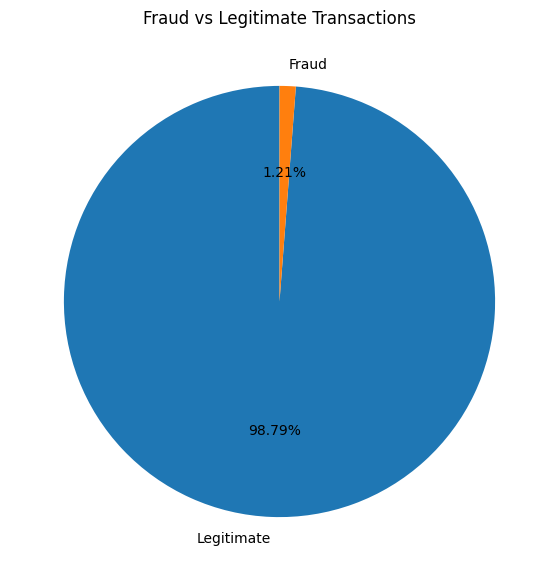

In [ ]:
fraud_counts = df['fraud'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    fraud_counts,
    labels=['Legitimate', 'Fraud'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Fraud vs Legitimate Transactions")

plt.show()

/tmp/ipykernel_97118/3939163509.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=age_stats, x='age', y='fraud_rate', palette='Reds_r')


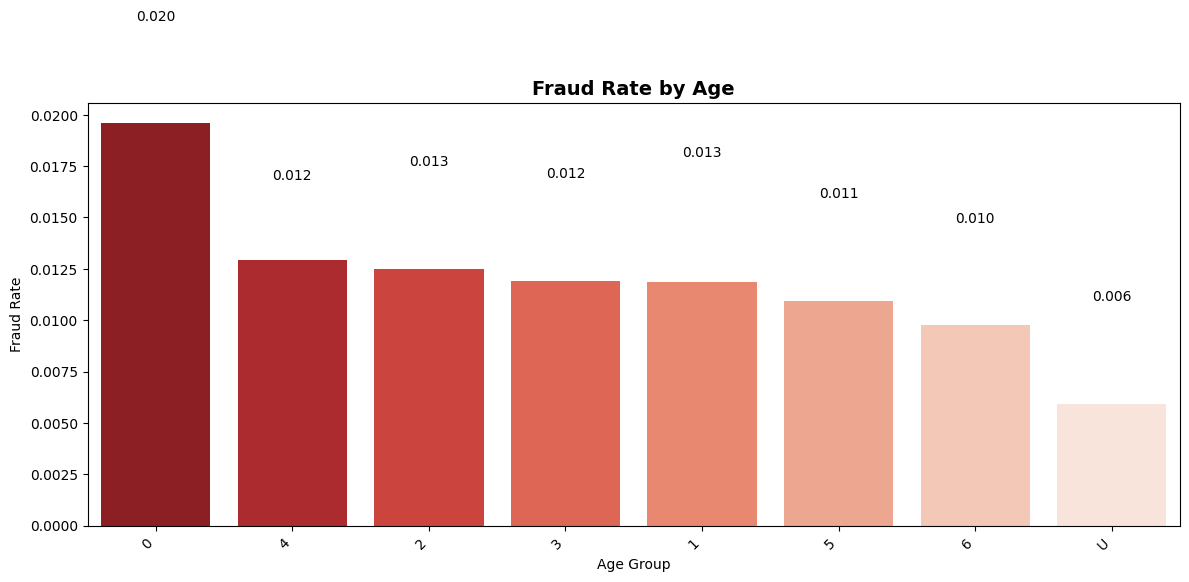

  age  fraud_rate  txn_count
0   0    0.019576       2452
4   4    0.012933     109025
2   2    0.012514     187310
3   3    0.011928     147131
1   1    0.011853      58131
5   5    0.010951      62642
6   6    0.009748      26774
7   U    0.005942       1178


/tmp/ipykernel_97118/3939163509.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_stats, x='gender', y='fraud_rate', palette='Reds_r')


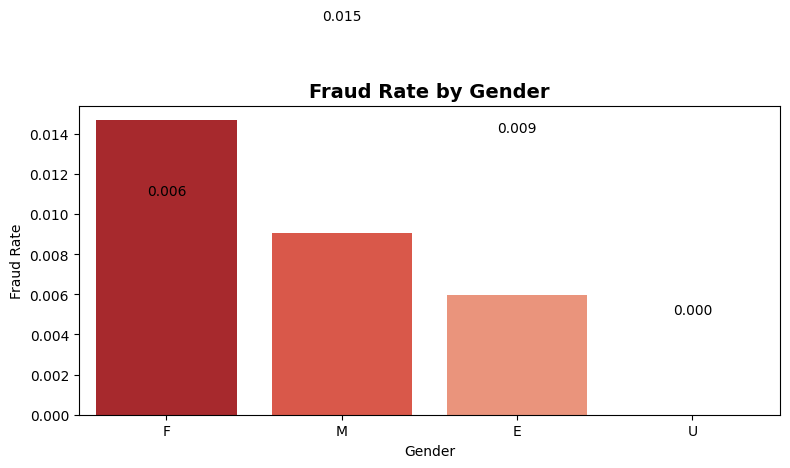

  gender  fraud_rate  txn_count
1      F    0.014660     324565
2      M    0.009073     268385
0      E    0.005942       1178
3      U    0.000000        515


/tmp/ipykernel_97118/3939163509.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cat_stats, x='category', y='fraud_rate', palette='Reds_r')


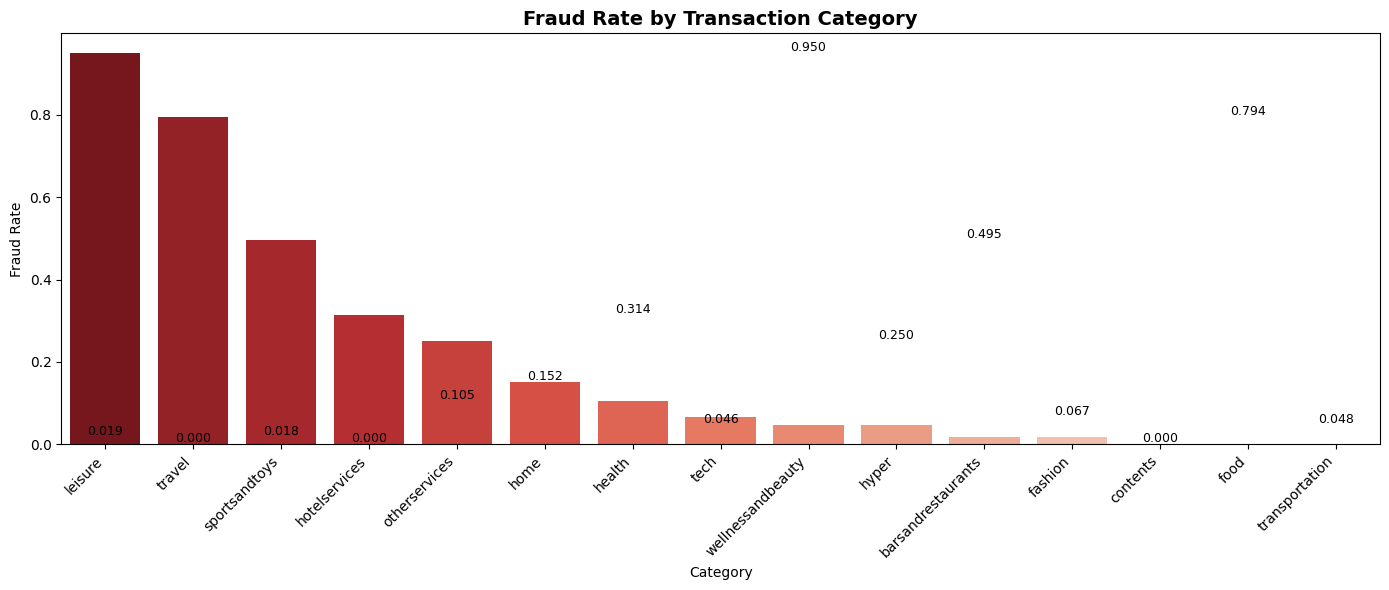

              category  fraud_rate  txn_count
8              leisure    0.949900        499
13              travel    0.793956        728
10       sportsandtoys    0.495252       4002
6        hotelservices    0.314220       1744
9        otherservices    0.250000        912
5                 home    0.152064       1986
4               health    0.105126      16133
11                tech    0.066667       2370
14   wellnessandbeauty    0.047594      15086
7                hyper    0.045917       6098
0   barsandrestaurants    0.018829       6373
2              fashion    0.017973       6454
1             contents    0.000000        885
3                 food    0.000000      26254
12      transportation    0.000000     505119


In [ ]:
age_stats = df.groupby('age').agg(
    fraud_rate=('fraud', 'mean'),
    txn_count=('fraud', 'count')
).reset_index().sort_values('fraud_rate', ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=age_stats, x='age', y='fraud_rate', palette='Reds_r')

for i, row in age_stats.iterrows():
    ax.text(i, row['fraud_rate'] + 0.005, f"{row['fraud_rate']:.3f}",
            ha='center', fontsize=10)

plt.title("Fraud Rate by Age", fontsize=14, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(age_stats)


gender_stats = df.groupby('gender').agg(
    fraud_rate=('fraud', 'mean'),
    txn_count=('fraud', 'count')
).reset_index().sort_values('fraud_rate', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_stats, x='gender', y='fraud_rate', palette='Reds_r')

for i, row in gender_stats.iterrows():
    ax.text(i, row['fraud_rate'] + 0.005, f"{row['fraud_rate']:.3f}",
            ha='center', fontsize=10)

plt.title("Fraud Rate by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

print(gender_stats)


cat_stats = df.groupby('category').agg(
    fraud_rate=('fraud', 'mean'),
    txn_count=('fraud', 'count')
).reset_index().sort_values('fraud_rate', ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=cat_stats, x='category', y='fraud_rate', palette='Reds_r')

for i, row in cat_stats.iterrows():
    ax.text(i, row['fraud_rate'] + 0.005, f"{row['fraud_rate']:.3f}",
            ha='center', fontsize=9)

plt.title("Fraud Rate by Transaction Category", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(cat_stats)

/tmp/ipykernel_97118/296880966.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


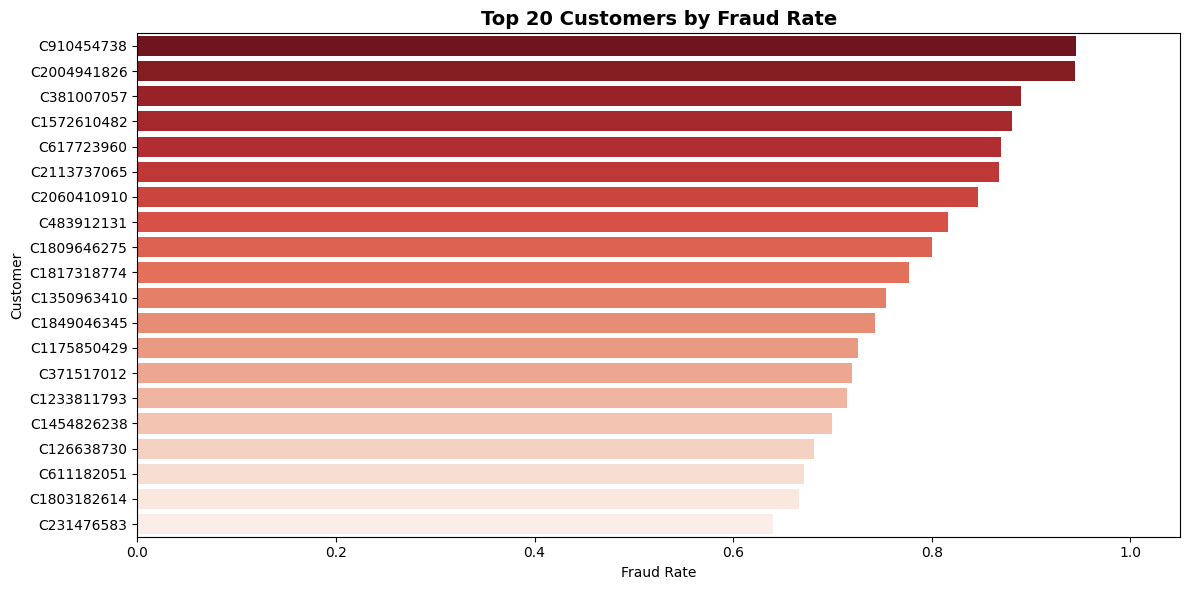

In [ ]:
customer_stats = df.groupby('customer').agg(
    txn_count=('fraud', 'count'),
    fraud_rate=('fraud', 'mean'),
    fraud_count=('fraud', 'sum')
).reset_index()
customer_stats = customer_stats[customer_stats['txn_count'] >= 5]
top20 = customer_stats.sort_values('fraud_rate', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top20,
    x='fraud_rate',
    y='customer',
    palette='Reds_r'
)
plt.title('Top 20 Customers by Fraud Rate', fontsize=14, fontweight='bold')
plt.xlabel('Fraud Rate')
plt.ylabel('Customer')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

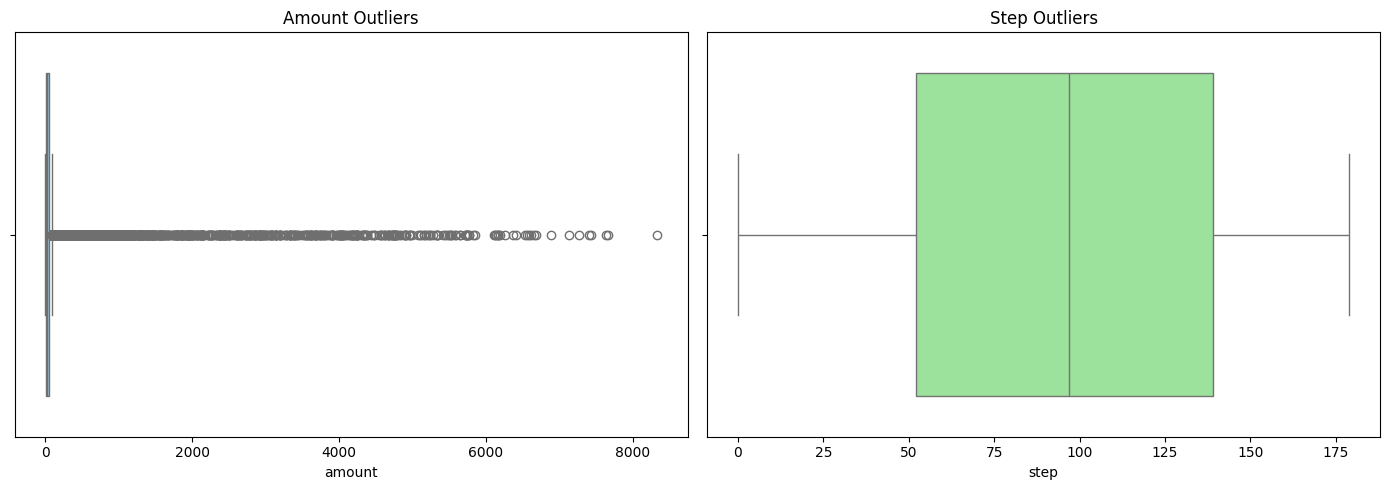

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df['amount'], ax=axes[0], color='skyblue')
axes[0].set_title('Amount Outliers')

sns.boxplot(x=df['step'], ax=axes[1], color='lightgreen')
axes[1].set_title('Step Outliers')
plt.tight_layout()
plt.show()

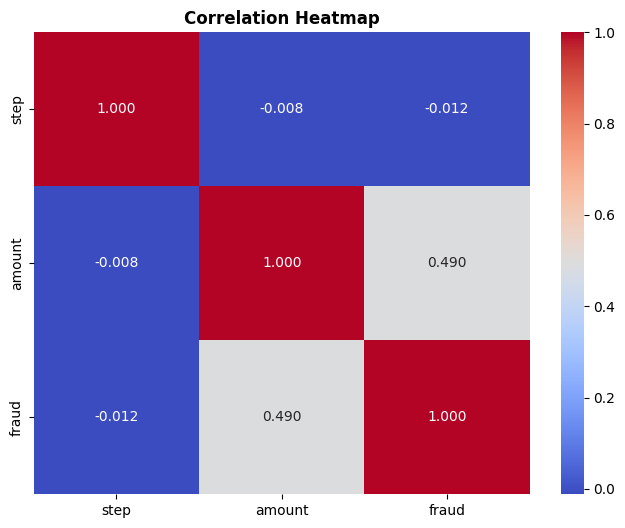

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['step', 'amount', 'fraud']].corr(),
            annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap', fontweight='bold')
plt.show()

In [ ]:
df['hour_of_day'] = df['step'] % 24
df['day_of_week'] = (df['step'] // 24) % 7

In [ ]:
df['customer_txn_count'] = df.groupby('customer')['step'].transform('count')
df['customer_avg_amount'] = df.groupby('customer')['amount'].transform('mean')
df['customer_std_amount'] = (
    df.groupby('customer')['amount'].transform('std').fillna(0)
)
df['customer_unique_merchants'] = (
    df.groupby('customer')['merchant'].transform('nunique')
)


df['merchant_txn_count'] = df.groupby('merchant')['step'].transform('count')


df['amount_vs_customer_avg'] = df['amount'] / (df['customer_avg_amount'] + 1e-6)
df['is_high_amount'] = (df['amount'] > df['amount'].quantile(0.95)).astype(int)
df['is_zero_amount'] = (df['amount'] == 0).astype(int)

In [ ]:
df['is_night'] = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] <= 6)).astype(int)

In [ ]:
cat_fraud_rate = df.groupby('category')['fraud'].mean()
df['category_fraud_rate'] = df['category'].map(cat_fraud_rate)

In [ ]:
df.shape

(594643, 20)

In [ ]:
X = df.drop('fraud', axis=1)
y = df['fraud']
X = X.drop(['customer', 'merchant'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
numeric_features = [
    'step', 'amount', 'hour_of_day', 'day_of_week',
    'customer_txn_count', 'customer_avg_amount', 'customer_std_amount',
    'merchant_txn_count', 'amount_vs_customer_avg', 'is_high_amount',
    'is_night', 'category_fraud_rate', 'customer_unique_merchants',
    'is_zero_amount'
]

categorical_features = ['age', 'gender', 'category']

In [ ]:
num_imputer = SimpleImputer(strategy='median')
X_train_num = num_imputer.fit_transform(X_train[numeric_features])
X_test_num  = num_imputer.transform(X_test[numeric_features])

In [ ]:
cat_imputer = SimpleImputer(strategy='constant', fill_value='U')
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = cat_imputer.fit_transform(X_train[categorical_features])
X_test_cat  = cat_imputer.transform(X_test[categorical_features])

X_train_cat = cat_encoder.fit_transform(X_train_cat)
X_test_cat  = cat_encoder.transform(X_test_cat)

In [ ]:
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed  = np.hstack([X_test_num, X_test_cat])

cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

In [ ]:
X_train_processed.shape

(475714, 41)

In [ ]:
X_test_processed.shape

(118929, 41)

In [ ]:
len(all_feature_names)

41

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
       "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
}

scalers = {
    "None": None,
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler(),
}


In [ ]:
results_list = []
trained_models = {}

for scaler_name, scaler in scalers.items():

    if scaler_name == "None":
        X_train_scaled = X_train_processed
        X_test_scaled  = X_test_processed
    else:
        X_train_scaled = scaler.fit_transform(X_train_processed)
        X_test_scaled  = scaler.transform(X_test_processed)

    for model_name, model in models.items():

        print(f"\n Training: {model_name} + {scaler_name}")

        model_clone = clone(model)

        model_clone.fit(X_train_scaled, y_train)

        y_pred = model_clone.predict(X_test_scaled)
        y_prob = model_clone.predict_proba(X_test_scaled)[:, 1]


        f1  = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)


        results_list.append({
            "Model": model_name,
            "Scaler": scaler_name,
            "F1": f1,
            "AUC-ROC": auc,
        })
        trained_models[f"{model_name}_{scaler_name}"] = model_clone

        print(f"    F1: {f1:.4f} | AUC: {auc:.4f}")




 Training: Logistic Regression + None
    F1: 0.4001 | AUC: 0.9964

 Training: Random Forest + None
    F1: 0.8426 | AUC: 0.9943

 Training: Gradient Boosting + None
    F1: 0.8466 | AUC: 0.9981

 Training: Logistic Regression + MinMaxScaler
    F1: 0.3648 | AUC: 0.9958

 Training: Random Forest + MinMaxScaler
    F1: 0.8398 | AUC: 0.9922

 Training: Gradient Boosting + MinMaxScaler
    F1: 0.8466 | AUC: 0.9981

 Training: Logistic Regression + StandardScaler
    F1: 0.4067 | AUC: 0.9966

 Training: Random Forest + StandardScaler
    F1: 0.8402 | AUC: 0.9922

 Training: Gradient Boosting + StandardScaler
    F1: 0.8466 | AUC: 0.9981


In [ ]:
results = pd.DataFrame(results_list)
results = results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)


print(results.to_string(index=False))


best_row = results.iloc[0]
best_key = f"{best_row['Model']}_{best_row['Scaler']}"
best_model = trained_models[best_key]

print(f"\n {best_row['Model']} + {best_row['Scaler']}")
print(f"   F1:      {best_row['F1']:.4f}")
print(f"   AUC-ROC: {best_row['AUC-ROC']:.4f}")


              Model         Scaler       F1  AUC-ROC
  Gradient Boosting           None 0.846576 0.998138
  Gradient Boosting StandardScaler 0.846576 0.998138
  Gradient Boosting   MinMaxScaler 0.846576 0.998138
Logistic Regression StandardScaler 0.406741 0.996647
Logistic Regression           None 0.400057 0.996416
Logistic Regression   MinMaxScaler 0.364835 0.995826
      Random Forest           None 0.842620 0.994255
      Random Forest   MinMaxScaler 0.839833 0.992187
      Random Forest StandardScaler 0.840152 0.992182

 Gradient Boosting + None
   F1:      0.8466
   AUC-ROC: 0.9981


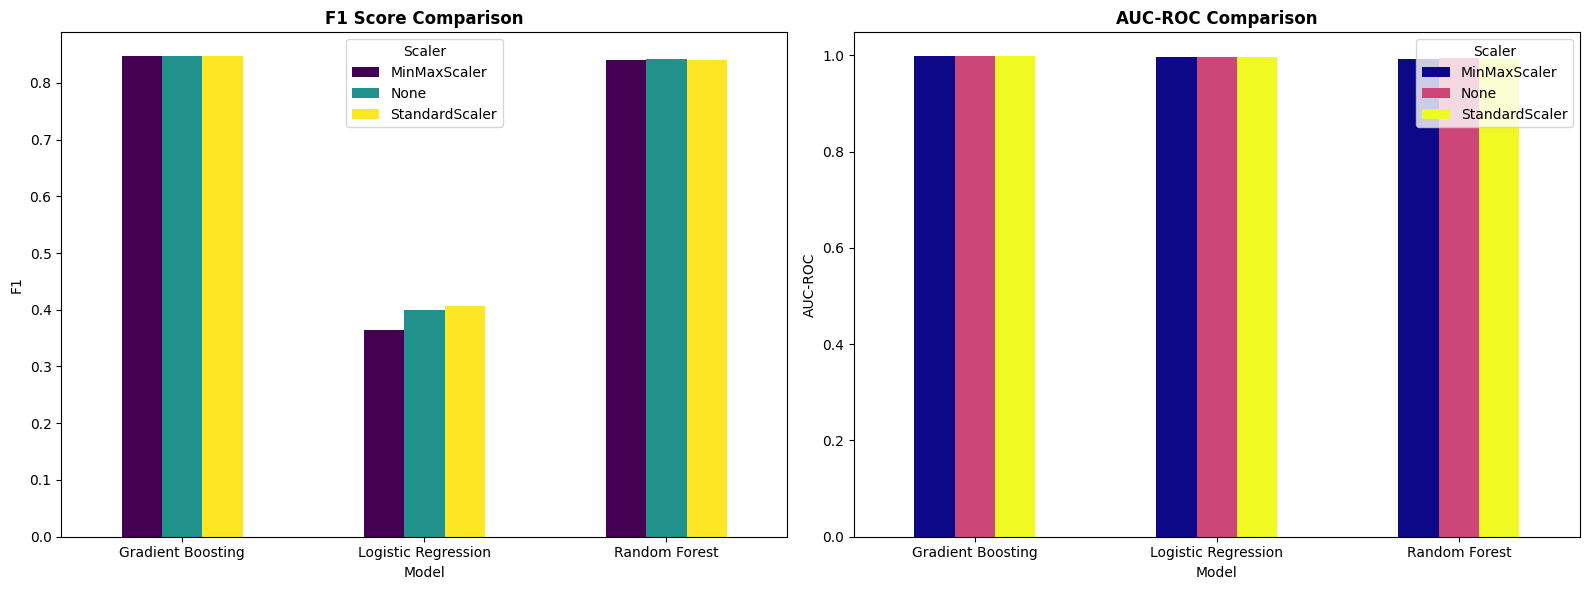

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_f1 = results.pivot(index='Model', columns='Scaler', values='F1')
pivot_f1.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('F1 Score Comparison', fontweight='bold')
axes[0].set_ylabel('F1')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Scaler')

pivot_auc = results.pivot(index='Model', columns='Scaler', values='AUC-ROC')
pivot_auc.plot(kind='bar', ax=axes[1], colormap='plasma')
axes[1].set_title('AUC-ROC Comparison', fontweight='bold')
axes[1].set_ylabel('AUC-ROC')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Scaler')

plt.tight_layout()
plt.show()

In [ ]:
best_scaler_name = best_row['Scaler']

if best_scaler_name == "None":
    X_test_best = X_test_processed
else:
    scaler_best = scalers[best_scaler_name]
    X_test_best = scaler_best.transform(X_test_processed)

y_pred_best = best_model.predict(X_test_best)
y_prob_best = best_model.predict_proba(X_test_best)[:, 1]

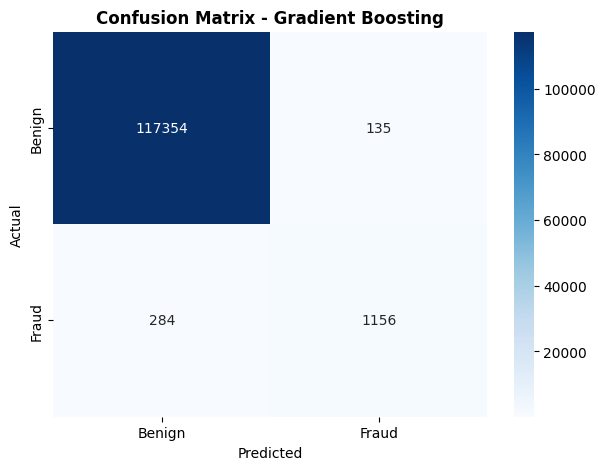

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Fraud'],
            yticklabels=['Benign', 'Fraud'])
plt.title(f'Confusion Matrix - {best_row["Model"]}', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
print("\n Classification Report:")
print(classification_report(y_test, y_pred_best,
                            target_names=['Benign', 'Fraud']))


 Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    117489
       Fraud       0.90      0.80      0.85      1440

    accuracy                           1.00    118929
   macro avg       0.95      0.90      0.92    118929
weighted avg       1.00      1.00      1.00    118929



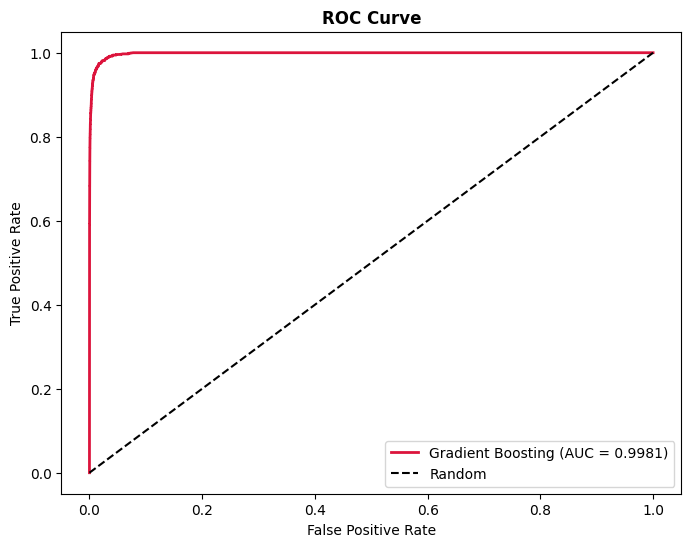

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2,
         label=f'{best_row["Model"]} (AUC = {best_row["AUC-ROC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend()
plt.show()

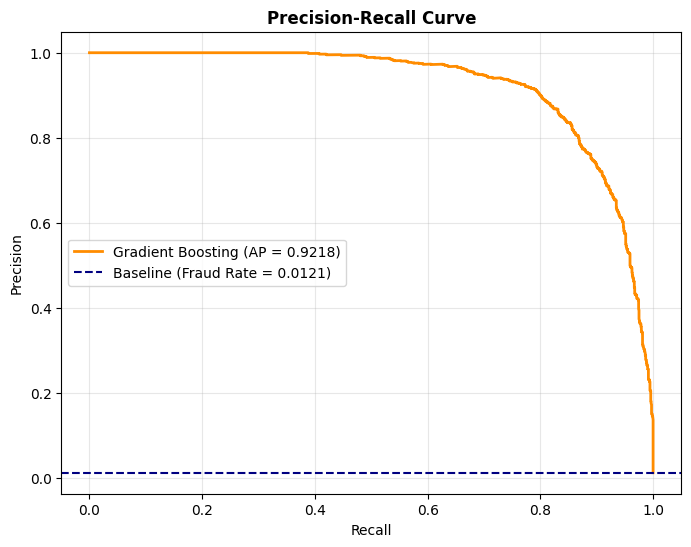

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_best)
ap = average_precision_score(y_test, y_prob_best)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'Gradient Boosting (AP = {ap:.4f})')
plt.axhline(y=y_test.mean(), color='navy', linestyle='--',
            label=f'Baseline (Fraud Rate = {y_test.mean():.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


 Top 15 Features:
                    feature  importance
                     amount    0.545715
         merchant_txn_count    0.134839
        category_fraud_rate    0.069206
        customer_std_amount    0.068931
        customer_avg_amount    0.064512
  customer_unique_merchants    0.031180
         customer_txn_count    0.017894
     amount_vs_customer_avg    0.017396
            category_travel    0.014320
             category_hyper    0.009677
     category_sportsandtoys    0.008380
            category_health    0.004379
     category_hotelservices    0.002625
category_barsandrestaurants    0.002009
 category_wellnessandbeauty    0.001999


/tmp/ipykernel_97118/3483903596.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


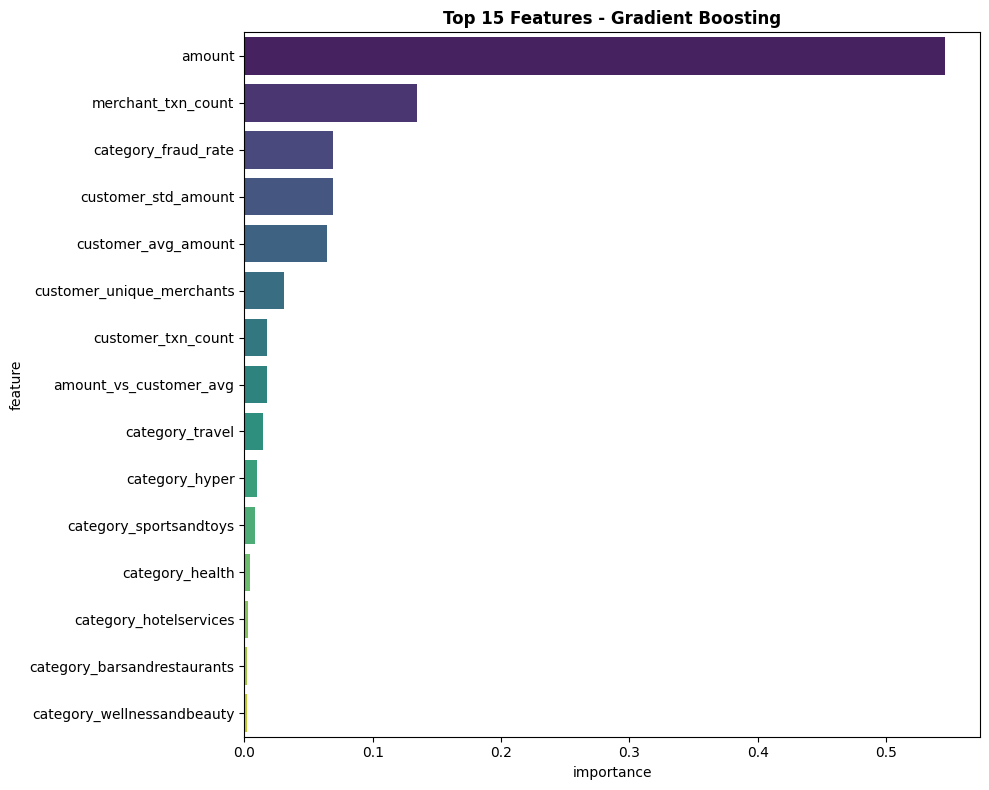

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = pd.DataFrame({
        'feature': all_feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print("\n Top 15 Features:")
    print(feat_imp.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature',
                data=feat_imp.head(15), palette='viridis')
    plt.title(f'Top 15 Features - {best_row["Model"]}', fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
samplers = {
    "No Sampling": None,
    "SMOTE": SMOTE(random_state=42),
    "RandomOverSampler": RandomOverSampler(random_state=42),
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
}
if best_scaler_name == "None":
    X_train_best = X_train_processed
    X_test_best_imb = X_test_processed
else:
    scaler_best = scalers[best_scaler_name]
    X_train_best = scaler_best.transform(X_train_processed)
    X_test_best_imb = scaler_best.transform(X_test_processed)

imbalance_results_list = []

for sampler_name, sampler in samplers.items():
    for model_name, model_template in models.items():

        print(f"\n {model_name} + {sampler_name}")

        model_clone = clone(model_template)


        if sampler_name == "No Sampling":
            X_train_res, y_train_res = X_train_best, y_train
        else:
            X_train_res, y_train_res = sampler.fit_resample(X_train_best, y_train)

        model_clone.fit(X_train_res, y_train_res)


        y_pred = model_clone.predict(X_test_best_imb)
        y_prob = model_clone.predict_proba(X_test_best_imb)[:, 1]

        f1  = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        imbalance_results_list.append({
            "Model": model_name,
            "Sampler": sampler_name,
            "F1": f1,
            "AUC-ROC": auc,
        })

        print(f"  F1: {f1:.4f} | AUC: {auc:.4f}")



 Logistic Regression + No Sampling
  F1: 0.4001 | AUC: 0.9964

 Random Forest + No Sampling
  F1: 0.8426 | AUC: 0.9943

 Gradient Boosting + No Sampling
  F1: 0.8466 | AUC: 0.9981

 Logistic Regression + SMOTE
  F1: 0.4055 | AUC: 0.9964

 Random Forest + SMOTE
  F1: 0.8348 | AUC: 0.9960

 Gradient Boosting + SMOTE
  F1: 0.6775 | AUC: 0.9977

 Logistic Regression + RandomOverSampler
  F1: 0.3998 | AUC: 0.9964

 Random Forest + RandomOverSampler
  F1: 0.8518 | AUC: 0.9943

 Gradient Boosting + RandomOverSampler
  F1: 0.5047 | AUC: 0.9981

 Logistic Regression + RandomUnderSampler
  F1: 0.3788 | AUC: 0.9962

 Random Forest + RandomUnderSampler
  F1: 0.4278 | AUC: 0.9973

 Gradient Boosting + RandomUnderSampler
  F1: 0.4572 | AUC: 0.9978


In [ ]:
imbalance_results = pd.DataFrame(imbalance_results_list)
imbalance_results = imbalance_results.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

In [ ]:
print(imbalance_results)

                  Model             Sampler        F1   AUC-ROC
0     Gradient Boosting         No Sampling  0.846576  0.998138
1     Gradient Boosting   RandomOverSampler  0.504723  0.998073
2     Gradient Boosting  RandomUnderSampler  0.457161  0.997784
3     Gradient Boosting               SMOTE  0.677549  0.997661
4         Random Forest  RandomUnderSampler  0.427841  0.997289
5   Logistic Regression         No Sampling  0.400057  0.996416
6   Logistic Regression               SMOTE  0.405538  0.996399
7   Logistic Regression   RandomOverSampler  0.399773  0.996367
8   Logistic Regression  RandomUnderSampler  0.378784  0.996245
9         Random Forest               SMOTE  0.834850  0.996012
10        Random Forest   RandomOverSampler  0.851772  0.994266
11        Random Forest         No Sampling  0.842620  0.994255


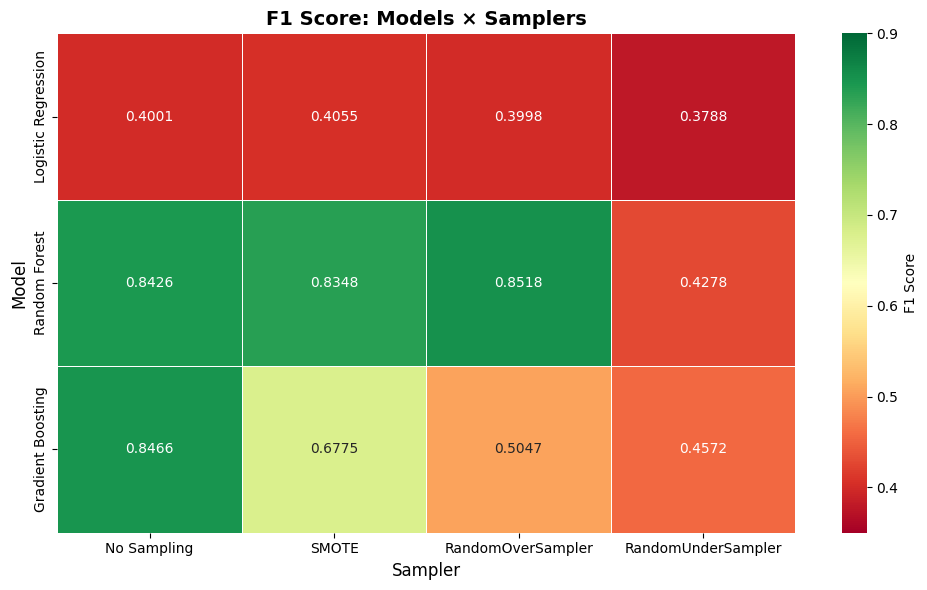

In [ ]:
plt.figure(figsize=(10, 6))

pivot_f1 = imbalance_results.pivot(
    index='Model', columns='Sampler', values='F1'
)

pivot_f1 = pivot_f1[['No Sampling', 'SMOTE', 'RandomOverSampler', 'RandomUnderSampler']]
pivot_f1 = pivot_f1.loc[['Logistic Regression', 'Random Forest', 'Gradient Boosting']]

sns.heatmap(
    pivot_f1,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0.35, vmax=0.90,
    linewidths=0.5,
    cbar_kws={'label': 'F1 Score'}
)

plt.title('F1 Score: Models × Samplers', fontsize=14, fontweight='bold')
plt.xlabel('Sampler', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

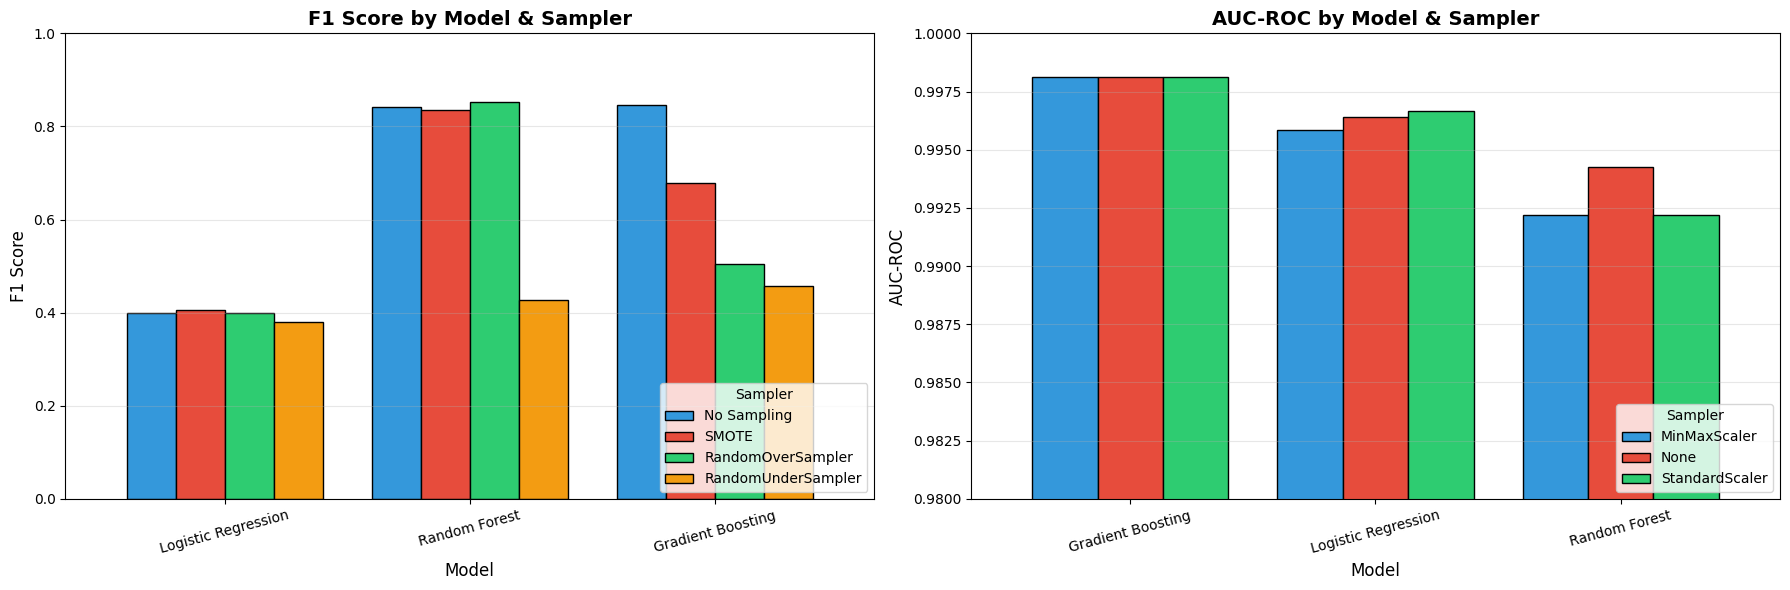

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

pivot_f1.plot(kind='bar', ax=axes[0],
              color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
              width=0.8, edgecolor='black')
axes[0].set_title('F1 Score by Model & Sampler', fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Sampler', loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)


pivot_auc.plot(kind='bar', ax=axes[1],
               color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
               width=0.8, edgecolor='black')
axes[1].set_title('AUC-ROC by Model & Sampler', fontsize=14, fontweight='bold')
axes[1].set_ylabel('AUC-ROC', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Sampler', loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0.98, 1.0)

plt.tight_layout()
plt.show()

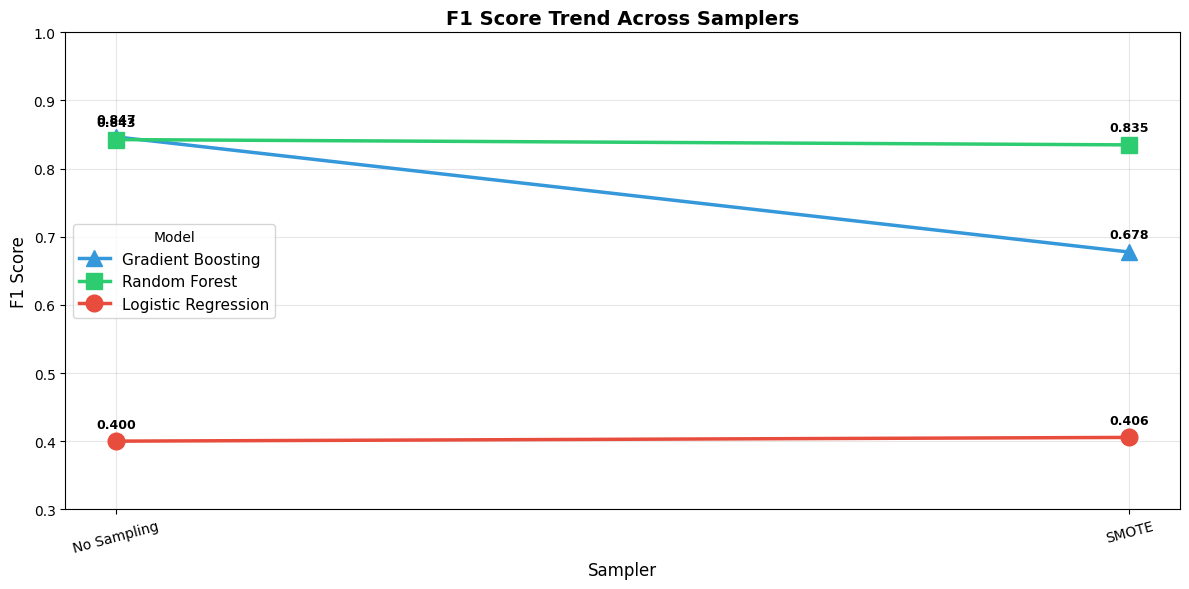

In [ ]:
plt.figure(figsize=(12, 6))

samplers_order = ['No Sampling', 'SMOTE', 'RandomOver', 'RandomUnder']
colors = {'Logistic Regression': '#e74c3c',
          'Random Forest': '#2ecc71',
          'Gradient Boosting': '#3498db'}
markers = {'Logistic Regression': 'o',
           'Random Forest': 's',
           'Gradient Boosting': '^'}

for model in imbalance_results['Model'].unique():
    model_data = imbalance_results[imbalance_results['Model'] == model]
    model_data = model_data.set_index('Sampler').reindex(samplers_order)

    plt.plot(
        samplers_order,
        model_data['F1'],
        marker=markers[model],
        linewidth=2.5,
        markersize=12,
        color=colors[model],
        label=model
    )

plt.title('F1 Score Trend Across Samplers', fontsize=14, fontweight='bold')
plt.xlabel('Sampler', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(title='Model', fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(rotation=15)
plt.ylim(0.3, 1.0)

for model in imbalance_results['Model'].unique():
    model_data = imbalance_results[imbalance_results['Model'] == model]
    model_data = model_data.set_index('Sampler').reindex(samplers_order)
    for i, val in enumerate(model_data['F1']):
        plt.text(i, val + 0.02, f'{val:.3f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report


baseline_model = HistGradientBoostingClassifier(
    max_iter=100, random_state=42
)
baseline_model.fit(X_train_processed, y_train)

y_pred_base = baseline_model.predict(X_test_processed)
y_prob_base = baseline_model.predict_proba(X_test_processed)[:, 1]

baseline_f1  = f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_prob_base)

print(f"\n Baseline F1: {baseline_f1:.4f} | AUC: {baseline_auc:.4f}")


param_grid = {
    'max_iter': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, None],
}

total = 1
for v in param_grid.values():
    total *= len(v)
print(f"\n Combinations: {total} x 3 folds = {total*3} trainings")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_processed, y_train)


print(f"\n Best Params: {grid_search.best_params_}")
print(f" Best CV F1:  {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test_processed)
y_prob_final = best_model.predict_proba(X_test_processed)[:, 1]

f1_final  = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)

print(f"\n Final Test F1:  {f1_final:.4f}")
print(f" Final Test AUC: {auc_final:.4f}")

comparison = pd.DataFrame({
    'Stage': ['Before', 'After'],
    'F1':    [baseline_f1, f1_final],
    'AUC':   [baseline_auc, auc_final],
})
print("\n Before vs After:")
print(comparison.to_string(index=False))

print("\n Classification Report:")
print(classification_report(y_test, y_pred_final,
                            target_names=['Benign', 'Fraud']))


 Baseline F1: 0.8573 | AUC: 0.9986

 Combinations: 12 x 3 folds = 36 trainings
Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Best Params: {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 200}
 Best CV F1:  0.8631

 Final Test F1:  0.8605
 Final Test AUC: 0.9987

 Before vs After:
 Stage       F1      AUC
Before 0.857349 0.998649
 After 0.860549 0.998740

 Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    117489
       Fraud       0.90      0.83      0.86      1440

    accuracy                           1.00    118929
   macro avg       0.95      0.91      0.93    118929
weighted avg       1.00      1.00      1.00    118929



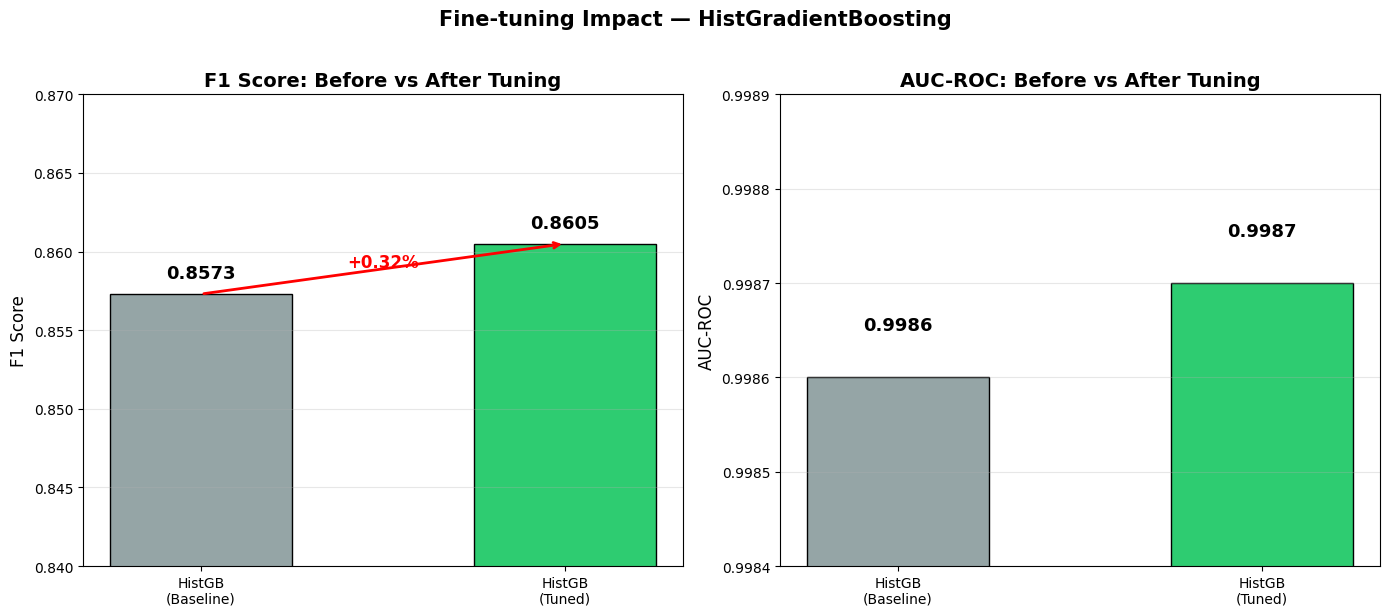

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

stages = ['HistGB\n(Baseline)', 'HistGB\n(Tuned)']
colors = ['#95a5a6', '#2ecc71']

f1_values = [0.8573, 0.8605]
bars1 = axes[0].bar(stages, f1_values, color=colors,
                     edgecolor='black', width=0.5)
axes[0].set_title('F1 Score: Before vs After Tuning',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('F1 Score', fontsize=12)
axes[0].set_ylim(0.84, 0.87)   # ← zoom على الفرق
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, f1_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.001,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)

axes[0].annotate('', xy=(1, 0.8605), xytext=(0, 0.8573),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))
axes[0].text(0.5, 0.859, '+0.32%', ha='center', color='red',
             fontweight='bold', fontsize=12)


auc_values = [0.9986, 0.9987]
bars2 = axes[1].bar(stages, auc_values, color=colors,
                     edgecolor='black', width=0.5)
axes[1].set_title('AUC-ROC: Before vs After Tuning',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('AUC-ROC', fontsize=12)
axes[1].set_ylim(0.9984, 0.9989)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, auc_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.00005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)

plt.suptitle('Fine-tuning Impact — HistGradientBoosting',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

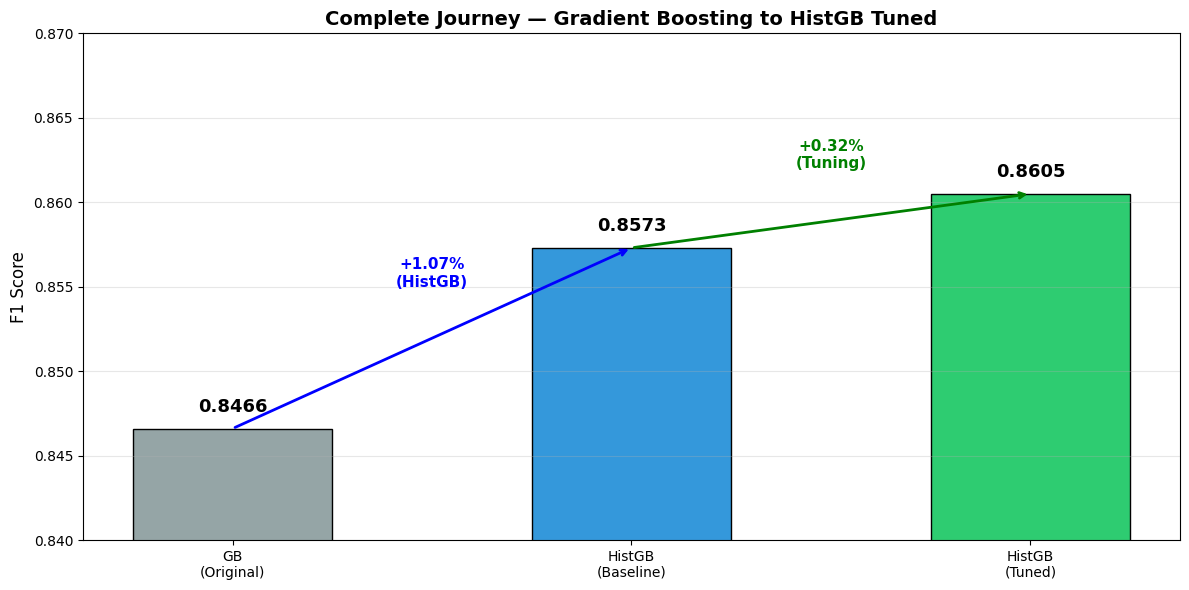

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

stages = ['GB\n(Original)', 'HistGB\n(Baseline)', 'HistGB\n(Tuned)']
f1_values = [0.8466, 0.8573, 0.8605]
colors = ['#95a5a6', '#3498db', '#2ecc71']

bars = ax.bar(stages, f1_values, color=colors,
              edgecolor='black', width=0.5)

ax.set_title('Complete Journey — Gradient Boosting to HistGB Tuned',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0.84, 0.87)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)

ax.annotate('', xy=(1, 0.8573), xytext=(0, 0.8466),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2))
ax.text(0.5, 0.855, '+1.07%\n(HistGB)', ha='center', color='blue',
        fontweight='bold', fontsize=11)

ax.annotate('', xy=(2, 0.8605), xytext=(1, 0.8573),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(1.5, 0.862, '+0.32%\n(Tuning)', ha='center', color='green',
        fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

os.makedirs('saved_work', exist_ok=True)

joblib.dump(X_train_processed, 'saved_work/X_train_processed.pkl')
joblib.dump(X_test_processed, 'saved_work/X_test_processed.pkl')
joblib.dump(y_train, 'saved_work/y_train.pkl')
joblib.dump(y_test, 'saved_work/y_test.pkl')

joblib.dump({
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'cat_encoder': cat_encoder,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'all_feature_names': all_feature_names,
}, 'saved_work/preprocessing.pkl')

joblib.dump(results, 'saved_work/results.pkl')
joblib.dump(imbalance_results, 'saved_work/imbalance_results.pkl')

joblib.dump(grid_search, 'saved_work/grid_search.pkl')
joblib.dump(best_model, 'saved_work/best_model.pkl')

final_package = {
    'model': best_model,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer,
    'cat_encoder': cat_encoder,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'all_feature_names': all_feature_names,
    'best_params': grid_search.best_params_,
    'test_f1': f1_final,
    'test_auc': auc_final,
}
joblib.dump(final_package, 'saved_work/final_fraud_model.pkl')

for f in os.listdir('saved_work'):
    size = os.path.getsize(f'saved_work/{f}') / (1024*1024)
    print(f"   - {f} ({size:.2f} MB)")

   - results.pkl (0.00 MB)
   - final_fraud_model.pkl (0.71 MB)
   - X_test_processed.pkl (37.20 MB)
   - best_model.pkl (0.71 MB)
   - grid_search.pkl (0.71 MB)
   - X_train_processed.pkl (148.81 MB)
   - preprocessing.pkl (0.00 MB)
   - y_train.pkl (14.52 MB)
   - y_test.pkl (3.63 MB)
   - imbalance_results.pkl (0.00 MB)
